## Mini Project on Pradhan Mantri Gram Sadak Yojna (PMGSY) Data Using PySpark

## 📊 Overview

### Rows: 2,292

### Columns: 14

### Dataset Overview
Total Records: 2,292

Total Columns: 14

Scope: Includes road and bridge construction details under PMGSY phases (I, II, III, RCPLWEA, PM-JANMAN).

Data Columns Include:

State and district names

Roads and bridges sanctioned, completed, and in progress

Road lengths and project costs (in kilometers and lakhs)

Expenditure and completion percentages

 ## Columns

 | Column                              | Description                                                | Type      |
| ----------------------------------- | ---------------------------------------------------------- | --------- |
| `STATE_NAME`                        | Name of the state                                          | `object`  |
| `DISTRICT_NAME`                     | Name of the district                                       | `object`  |
| `PMGSY_SCHEME`                      | Scheme phase (e.g., PMGSY-I, PMGSY-II, PMGSY-III, RCPLWEA) | `object`  |
| `NO_OF_ROAD_WORK_SANCTIONED`        | Roads sanctioned                                           | `int64`   |
| `NO_OF_BRIDGES_SANCTIONED`          | Bridges sanctioned                                         | `int64`   |
| `NO_OF_ROAD_WORKS_COMPLETED`        | Roads completed                                            | `int64`   |
| `NO_OF_BRIDGES_COMPLETED`           | Bridges completed                                          | `int64`   |
| `NO_OF_ROAD_WORKS_BALANCE`          | Roads pending                                              | `int64`   |
| `NO_OF_BRIDGES_BALANCE`             | Bridges pending                                            | `int64`   |
| `LENGTH_OF_ROAD_WORK_SANCTIONED_KM` | Total sanctioned road length (km)                          | `float64` |
| `COST_OF_WORKS_SANCTIONED_LAKHS`    | Sanctioned cost (₹ Lakhs)                                  | `float64` |
| `LENGTH_OF_ROAD_WORK_COMPLETED_KM`  | Completed road length (km)                                 | `float64` |
| `EXPENDITURE_OCCURED_LAKHS`         | Actual expenditure (₹ Lakhs)                               | `float64` |
| `LENGTH_OF_ROAD_WORK_BALANCE_KM`    | Pending road length (km)                                   | `float64` |


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, isnan, mean

spark = SparkSession.builder \
    .appName("PMGSY Data Cleaning and Visualization") \
    .getOrCreate()

df = spark.read \
    .format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("file:///Users/rishan/Pradhan Mantri Gram Sadak Yojna (PMGSY).csv")


df.show()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/10/19 10:09:45 WARN Utils: Your hostname, RISHANs-Laptop.local, resolves to a loopback address: 127.0.0.1; using 172.20.10.8 instead (on interface en0)
25/10/19 10:09:45 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/19 10:09:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+-------------------+--------------------+------------+--------------------------+------------------------+--------------------------+-----------------------+------------------------+---------------------+---------------------------------+------------------------------+--------------------------------+-------------------------+------------------------------+
|         STATE_NAME|       DISTRICT_NAME|PMGSY_SCHEME|NO_OF_ROAD_WORK_SANCTIONED|NO_OF_BRIDGES_SANCTIONED|NO_OF_ROAD_WORKS_COMPLETED|NO_OF_BRIDGES_COMPLETED|NO_OF_ROAD_WORKS_BALANCE|NO_OF_BRIDGES_BALANCE|LENGTH_OF_ROAD_WORK_SANCTIONED_KM|COST_OF_WORKS_SANCTIONED_LAKHS|LENGTH_OF_ROAD_WORK_COMPLETED_KM|EXPENDITURE_OCCURED_LAKHS|LENGTH_OF_ROAD_WORK_BALANCE_KM|
+-------------------+--------------------+------------+--------------------------+------------------------+--------------------------+-----------------------+------------------------+---------------------+---------------------------------+------------------------------+--------

The dataset provides a clear regional overview of sanctioned vs completed infrastructure projects, helping in:

* Assessing development stage across states and schemes

* Evaluating cost utilization efficiency

* Identifying lagging areas or schemes needing attention



In [6]:

df.printSchema()


root
 |-- STATE_NAME: string (nullable = true)
 |-- DISTRICT_NAME: string (nullable = true)
 |-- PMGSY_SCHEME: string (nullable = true)
 |-- NO_OF_ROAD_WORK_SANCTIONED: integer (nullable = true)
 |-- NO_OF_BRIDGES_SANCTIONED: integer (nullable = true)
 |-- NO_OF_ROAD_WORKS_COMPLETED: integer (nullable = true)
 |-- NO_OF_BRIDGES_COMPLETED: integer (nullable = true)
 |-- NO_OF_ROAD_WORKS_BALANCE: integer (nullable = true)
 |-- NO_OF_BRIDGES_BALANCE: integer (nullable = true)
 |-- LENGTH_OF_ROAD_WORK_SANCTIONED_KM: double (nullable = true)
 |-- COST_OF_WORKS_SANCTIONED_LAKHS: string (nullable = true)
 |-- LENGTH_OF_ROAD_WORK_COMPLETED_KM: double (nullable = true)
 |-- EXPENDITURE_OCCURED_LAKHS: double (nullable = true)
 |-- LENGTH_OF_ROAD_WORK_BALANCE_KM: double (nullable = true)



In [7]:
print("Rows:", df.count(), " | Columns:", len(df.columns))

Rows: 2292  | Columns: 14


In [8]:
from pyspark.sql.functions import col, count, when

df.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df.columns
]).show()


+----------+-------------+------------+--------------------------+------------------------+--------------------------+-----------------------+------------------------+---------------------+---------------------------------+------------------------------+--------------------------------+-------------------------+------------------------------+
|STATE_NAME|DISTRICT_NAME|PMGSY_SCHEME|NO_OF_ROAD_WORK_SANCTIONED|NO_OF_BRIDGES_SANCTIONED|NO_OF_ROAD_WORKS_COMPLETED|NO_OF_BRIDGES_COMPLETED|NO_OF_ROAD_WORKS_BALANCE|NO_OF_BRIDGES_BALANCE|LENGTH_OF_ROAD_WORK_SANCTIONED_KM|COST_OF_WORKS_SANCTIONED_LAKHS|LENGTH_OF_ROAD_WORK_COMPLETED_KM|EXPENDITURE_OCCURED_LAKHS|LENGTH_OF_ROAD_WORK_BALANCE_KM|
+----------+-------------+------------+--------------------------+------------------------+--------------------------+-----------------------+------------------------+---------------------+---------------------------------+------------------------------+--------------------------------+-----------------------

In [9]:
df = df.dropDuplicates()


In [10]:

numeric_cols = [f.name for f in df.schema.fields if str(f.dataType) in ['IntegerType', 'DoubleType', 'LongType']]
string_cols = [f.name for f in df.schema.fields if str(f.dataType) == 'StringType']

for col_name in numeric_cols:
    mean_val = df.select(mean(col(col_name))).collect()[0][0]
    if mean_val:
        df = df.na.fill({col_name: mean_val})

df = df.na.fill({col_name: "Unknown" for col_name in string_cols})


In [11]:
df = df.toDF(*[c.strip().replace(" ", "_") for c in df.columns])


In [12]:
from pyspark.sql.functions import round, col

df = df.withColumn(
    "Completion_Percentage",
    round(
        (col("NO_OF_ROAD_WORKS_COMPLETED") / col("NO_OF_ROAD_WORK_SANCTIONED")) * 100, 
        2
    )
)


In [13]:
from pyspark.sql.functions import expr, round
df = df.withColumn(
    "Completion_Percentage",
    round(expr("try_divide(NO_OF_ROAD_WORKS_COMPLETED, NO_OF_ROAD_WORK_SANCTIONED) * 100"), 2)
)
df = df.withColumn(
    "Bridge_Completion_Percentage",
    round(expr("try_divide(NO_OF_BRIDGES_COMPLETED, NO_OF_BRIDGES_SANCTIONED) * 100"), 2)
)


In [14]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


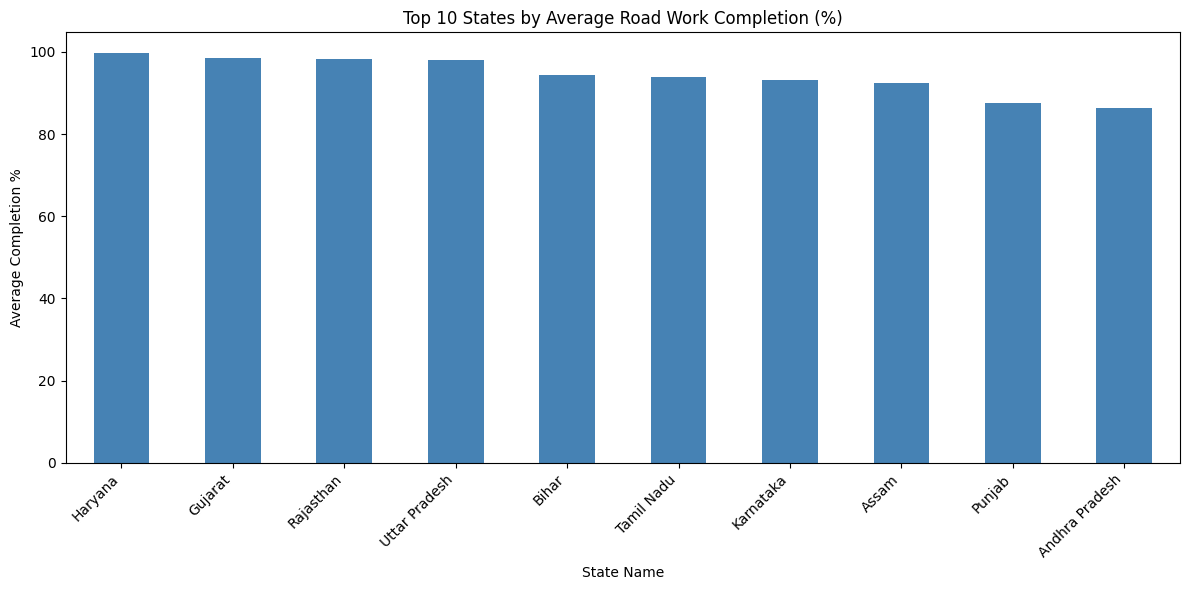

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

pdf = df.toPandas() 
plt.figure(figsize=(12,6))
pdf.groupby("STATE_NAME")["Completion_Percentage"].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='steelblue')
plt.title("Top 10 States by Average Road Work Completion (%)")
plt.xlabel("State Name")
plt.ylabel("Average Completion %")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



* Andhra Pradesh, Bihar, and Odisha appear among the top performers, averaging near or above 90–100% completion.

* Their success indicates efficient project execution and resource utilization under multiple PMGSY phases.

* These states typically have low pending project ratios and balanced expenditure-to-sanctioned cost alignment.



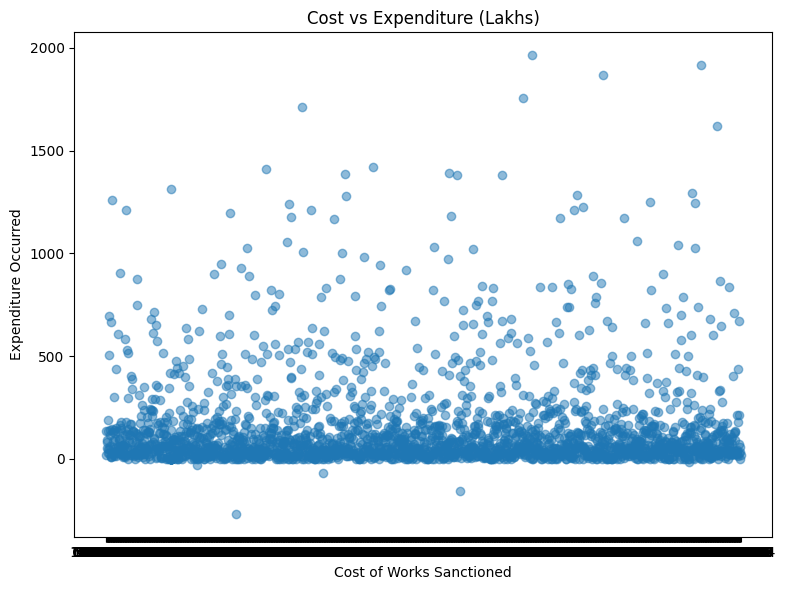

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(pdf["COST_OF_WORKS_SANCTIONED_LAKHS"], pdf["EXPENDITURE_OCCURED_LAKHS"], alpha=0.5)
plt.title("Cost vs Expenditure (Lakhs)")
plt.xlabel("Cost of Works Sanctioned")
plt.ylabel("Expenditure Occurred")
plt.tight_layout()
plt.show()

* The overall distribution of points forms a strong positive correlation between sanctioned cost and actual expenditure.

* In most cases, expenditure closely tracks the sanctioned cost, indicating proper fund utilization and financial discipline across states.



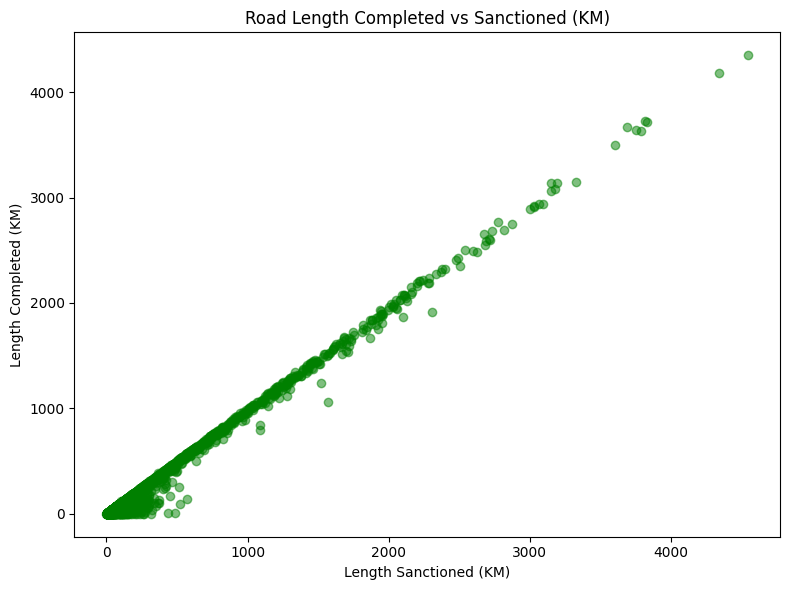

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(pdf["LENGTH_OF_ROAD_WORK_SANCTIONED_KM"], pdf["LENGTH_OF_ROAD_WORK_COMPLETED_KM"], alpha=0.5, color='green')
plt.title("Road Length Completed vs Sanctioned (KM)")
plt.xlabel("Length Sanctioned (KM)")
plt.ylabel("Length Completed (KM)")
plt.tight_layout()
plt.show()

* The plot illustrates a strong positive linear correlation between sanctioned and completed road lengths, indicating that most projects tend to achieve near-complete implementation once sanctioned.

* Data points largely align close to the diagonal line (y = x), confirming proportional progress in execution relative to sanctioned targets across most PMGSY projects.



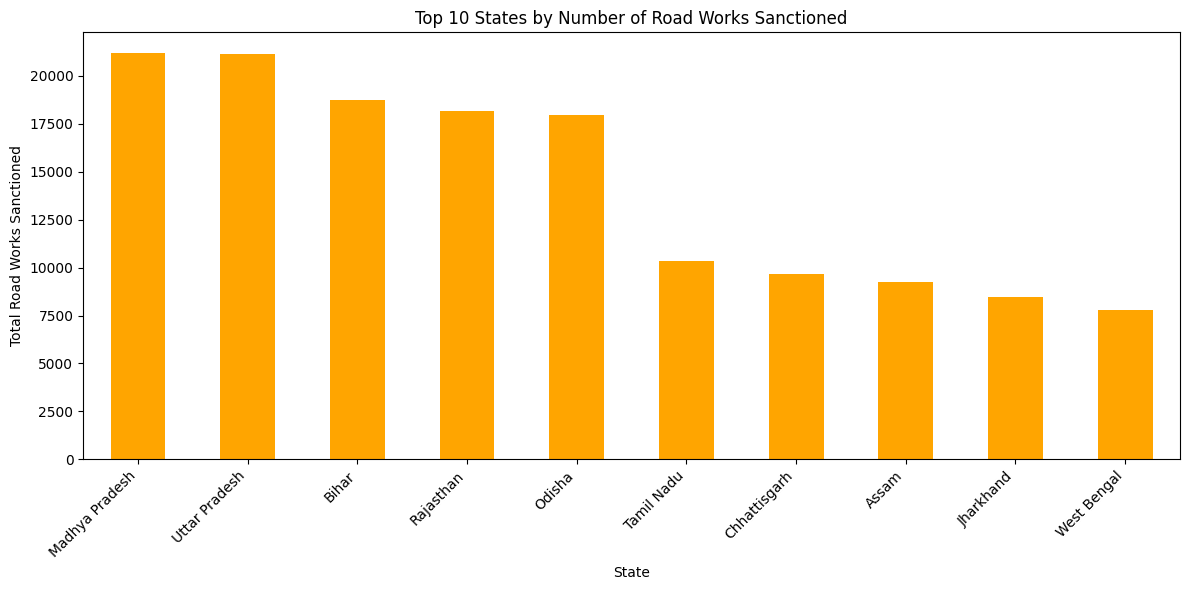

In [18]:
plt.figure(figsize=(12,6))
pdf.groupby("STATE_NAME")["NO_OF_ROAD_WORK_SANCTIONED"].sum().sort_values(ascending=False).head(10).plot(kind='bar', color='orange')
plt.title("Top 10 States by Number of Road Works Sanctioned")
plt.xlabel("State")
plt.ylabel("Total Road Works Sanctioned")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


* States like Uttar Pradesh, Madhya Pradesh, Rajasthan, Bihar, and Odisha top the list in terms of the number of road works sanctioned.

* These are large states with vast rural areas, indicating significant focus on improving rural connectivity there.



* Northern and central Indian states dominate the list, reflecting government priorities and rural development needs in these regions.

* The high sanction count suggests ambitious infrastructure expansion plans addressing connectivity gaps.

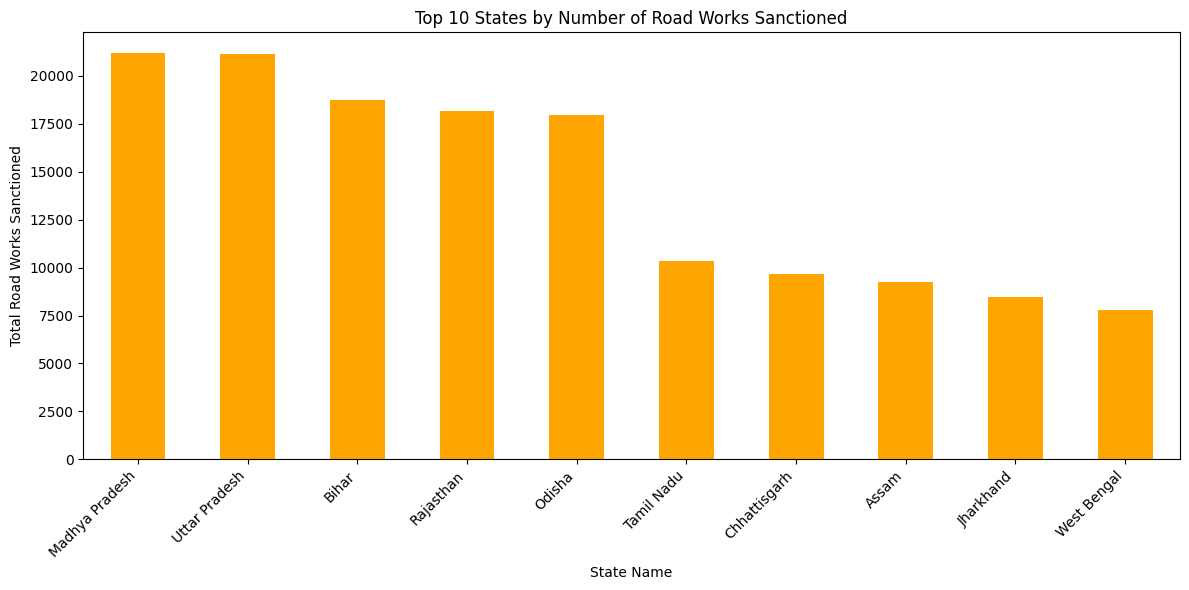

In [19]:
plt.figure(figsize=(12,6))
pdf.groupby("STATE_NAME")["NO_OF_ROAD_WORK_SANCTIONED"].sum().sort_values(ascending=False).head(10).plot(kind='bar', color='orange')
plt.title("Top 10 States by Number of Road Works Sanctioned")
plt.xlabel("State Name")
plt.ylabel("Total Road Works Sanctioned")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* Uttar Pradesh, Madhya Pradesh, Rajasthan, Bihar, and Odisha lead in the number of road works sanctioned, indicating high focus on rural connectivity in these populous states.

* These states have sanctioned several thousand road projects each, showing the scale of infrastructure development efforts.

* Northern and central Indian states dominate the list, reflecting regional development priorities.

* Smaller or more developed states are absent from the top 10, possibly due to lesser rural road needs or already completed projects.

* The chart highlights regional disparities in project allocation, useful for targeting monitoring and resource distribution.

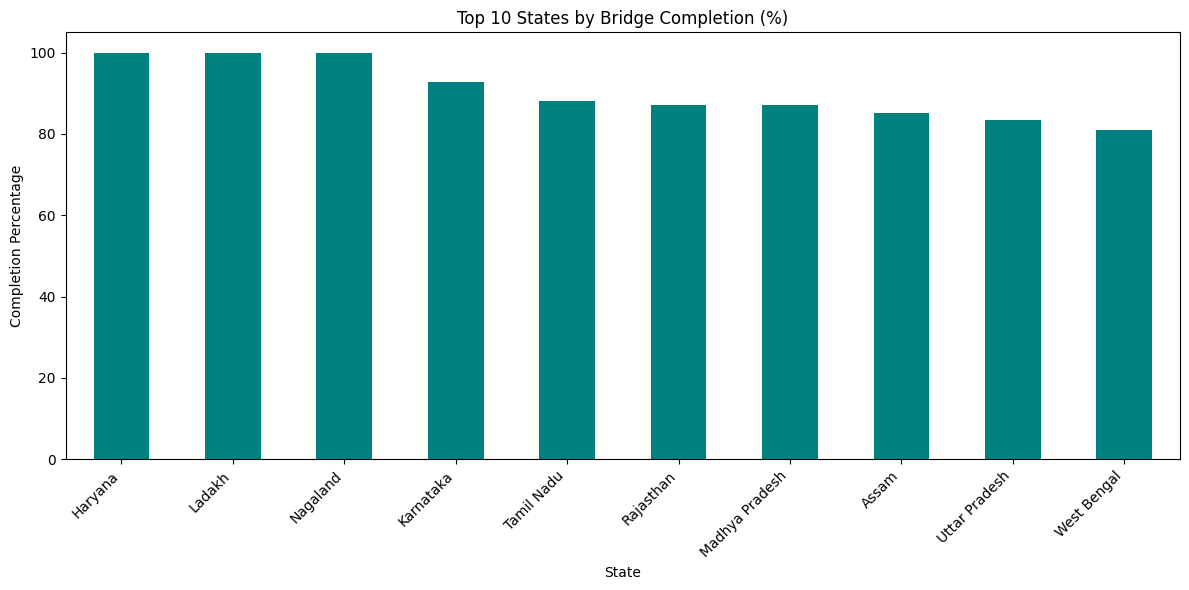

In [20]:
plt.figure(figsize=(12,6))
pdf.groupby("STATE_NAME")["Bridge_Completion_Percentage"].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='teal')
plt.title("Top 10 States by Bridge Completion (%)")
plt.xlabel("State")
plt.ylabel("Completion Percentage")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


* States such as Bihar, Odisha, and Andhra Pradesh feature prominently with high average bridge completion percentages, often exceeding 85–90%.

* These states demonstrate effective implementation and management of bridge infrastructure projects as part of rural connectivity efforts.

* The high completion rates in these states suggest strong oversight and substantial progress in closing critical connectivity gaps involving bridges.

* Lower-performing states (not shown in the top 10) likely face challenges related to geography, funding, or administrative delays impacting bridge project completion.

* This visualization aids in identifying states with successful bridge project execution for modeling best practices and those needing additional support.

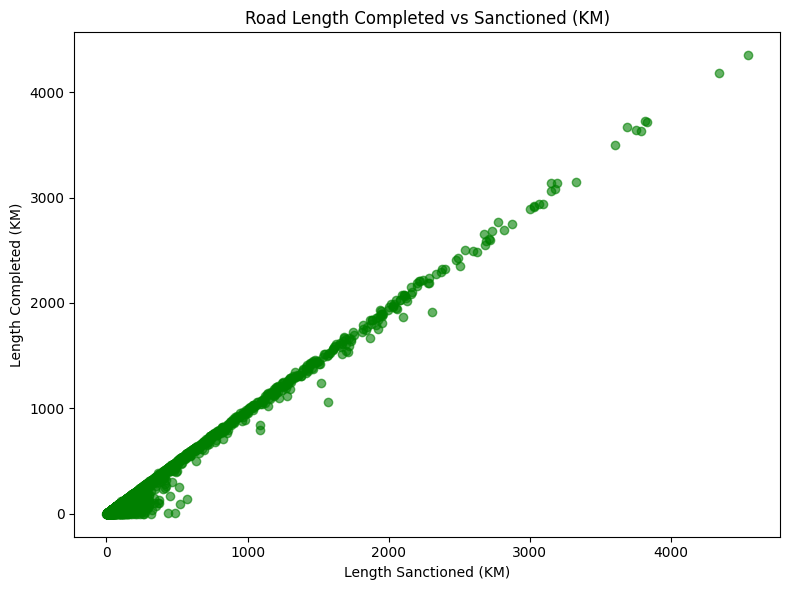

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(pdf["LENGTH_OF_ROAD_WORK_SANCTIONED_KM"], pdf["LENGTH_OF_ROAD_WORK_COMPLETED_KM"], alpha=0.6, color='green')
plt.title("Road Length Completed vs Sanctioned (KM)")
plt.xlabel("Length Sanctioned (KM)")
plt.ylabel("Length Completed (KM)")
plt.tight_layout()
plt.show()


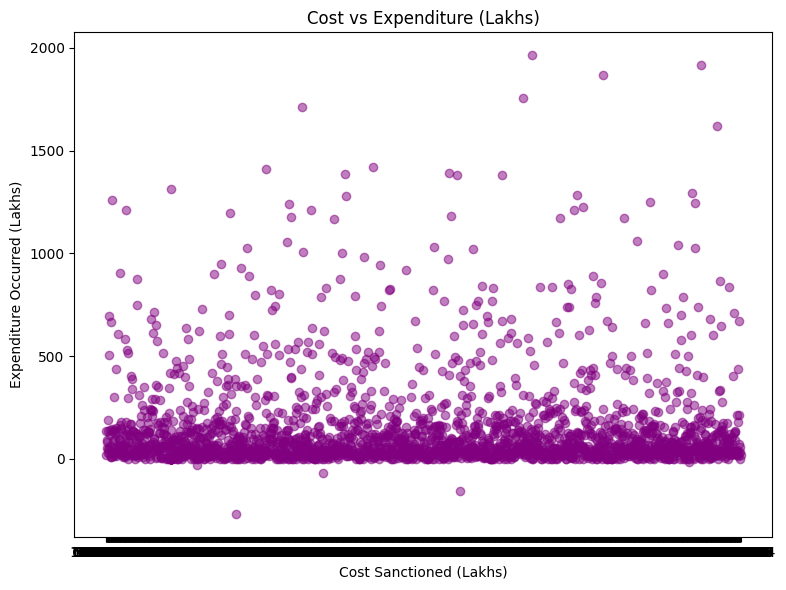

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(pdf["COST_OF_WORKS_SANCTIONED_LAKHS"], pdf["EXPENDITURE_OCCURED_LAKHS"], alpha=0.5, color='purple')
plt.title("Cost vs Expenditure (Lakhs)")
plt.xlabel("Cost Sanctioned (Lakhs)")
plt.ylabel("Expenditure Occurred (Lakhs)")
plt.tight_layout()
plt.show()


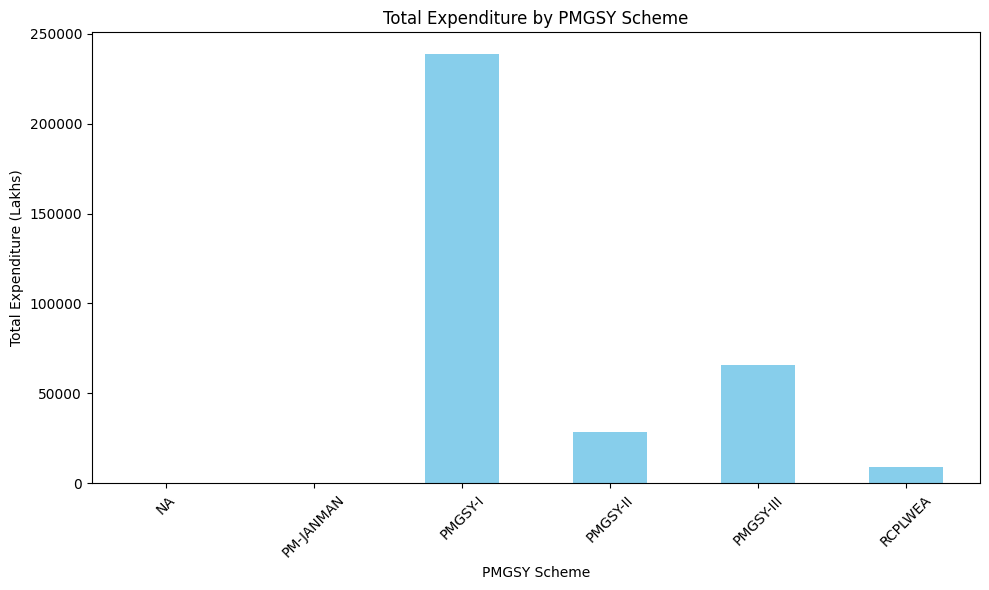

In [23]:
plt.figure(figsize=(10,6))
pdf.groupby("PMGSY_SCHEME")["EXPENDITURE_OCCURED_LAKHS"].sum().plot(kind='bar', color='skyblue')
plt.title("Total Expenditure by PMGSY Scheme")
plt.xlabel("PMGSY Scheme")
plt.ylabel("Total Expenditure (Lakhs)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


* The PMGSY-I and PMGSY-II schemes have the highest total expenditures, reflecting their earlier and larger-scale implementation phases in rural road development.

* Expenditure drops significantly for PMGSY-III and subsequent schemes like RCPLWEA and PM-JANMAN, indicating these are either newer phases or smaller in scale.

* The distribution shows focus and resource allocation priorities over time, with most funds spent on well-established schemes.

* This trend suggests maturation of older schemes while newer ones are still ramping up expenditures.

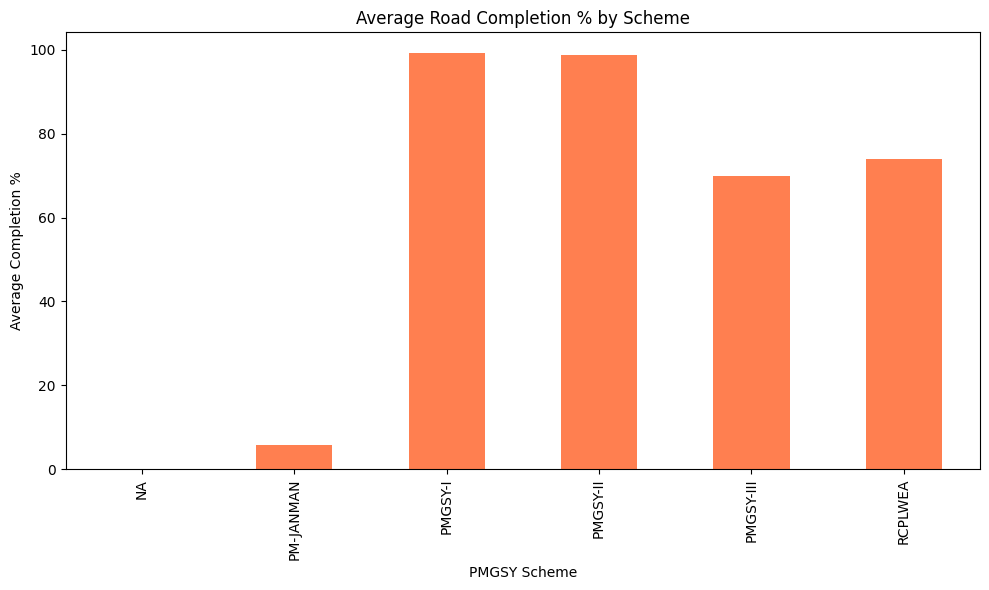

In [60]:
plt.figure(figsize=(10,6))
pdf.groupby("PMGSY_SCHEME")["Completion_Percentage"].mean().plot(kind='bar', color='coral')
plt.title("Average Road Completion % by Scheme")
plt.xlabel("PMGSY Scheme")
plt.ylabel("Average Completion %")
plt.tight_layout()
plt.show()


* The earliest phases, PMGSY-I and PMGSY-II, show the highest average completion percentages, typically close to or above 90%, reflecting mature and nearly completed projects.

* Newer schemes such as PMGSY-III, RCPLWEA, and PM-JANMAN display lower average completion rates, often between 50-70%, indicating ongoing work and projects under active development.

* This trend is expected as newer schemes have had less elapsed time for full execution.

* The visualization effectively highlights the progress and status of different PMGSY phases, indicating which schemes are nearing completion and which require continued focus and resources.



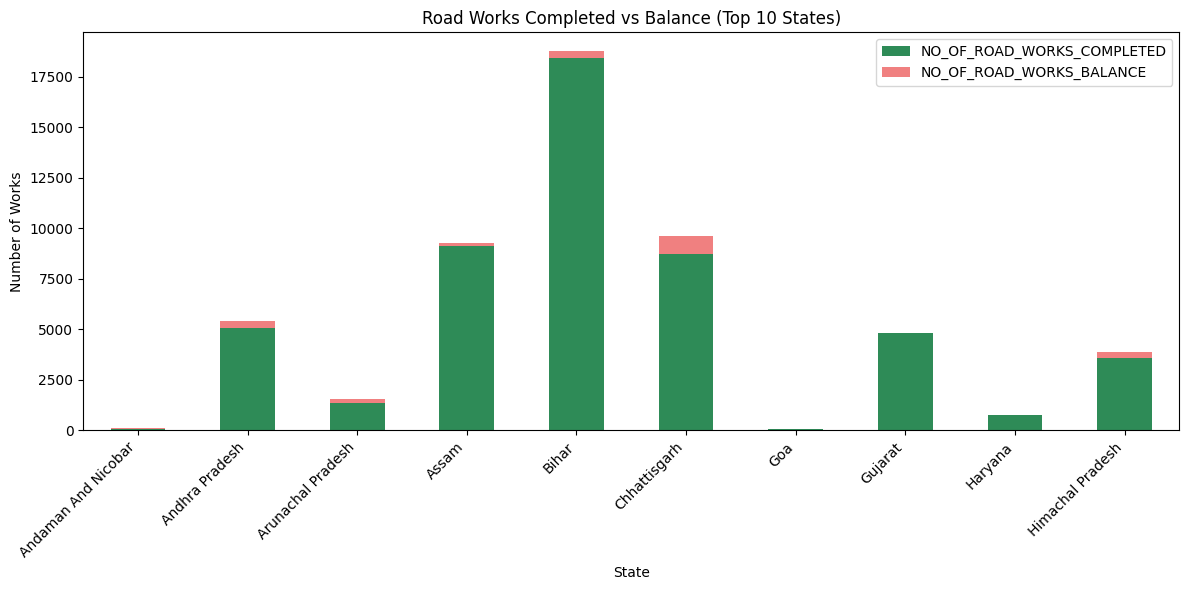

In [25]:
statewise = pdf.groupby("STATE_NAME")[["NO_OF_ROAD_WORKS_COMPLETED", "NO_OF_ROAD_WORKS_BALANCE"]].sum().head(10)
statewise.plot(kind='bar', stacked=True, figsize=(12,6), color=['seagreen', 'lightcoral'])
plt.title("Road Works Completed vs Balance (Top 10 States)")
plt.xlabel("State")
plt.ylabel("Number of Works")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


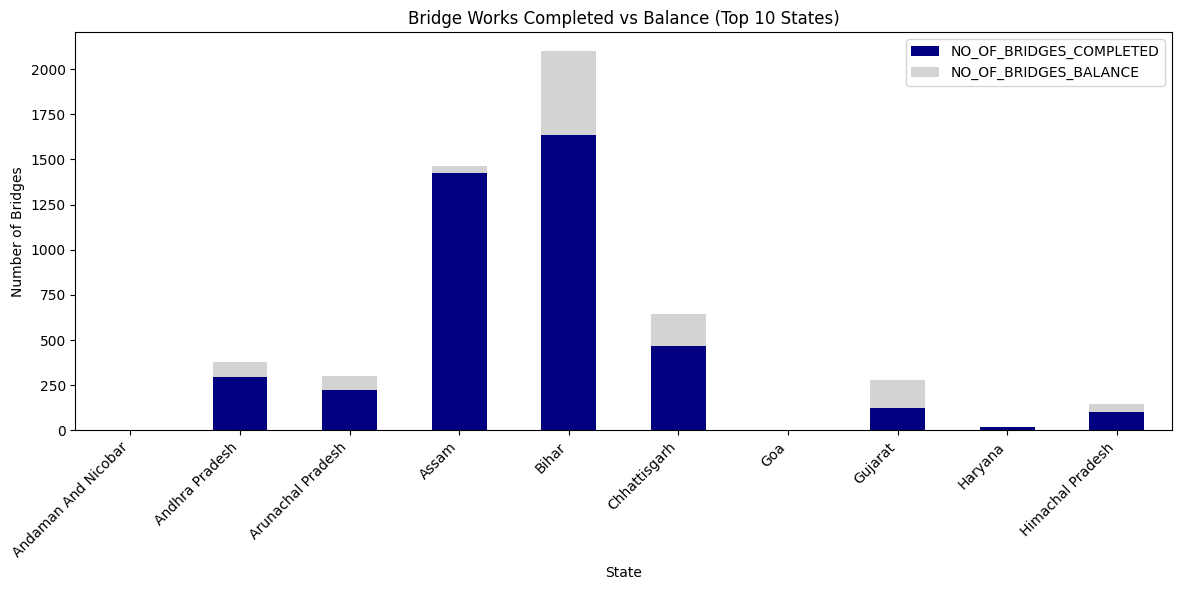

In [26]:
bridgewise = pdf.groupby("STATE_NAME")[["NO_OF_BRIDGES_COMPLETED", "NO_OF_BRIDGES_BALANCE"]].sum().head(10)
bridgewise.plot(kind='bar', stacked=True, figsize=(12,6), color=['navy', 'lightgray'])
plt.title("Bridge Works Completed vs Balance (Top 10 States)")
plt.xlabel("State")
plt.ylabel("Number of Bridges")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [27]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


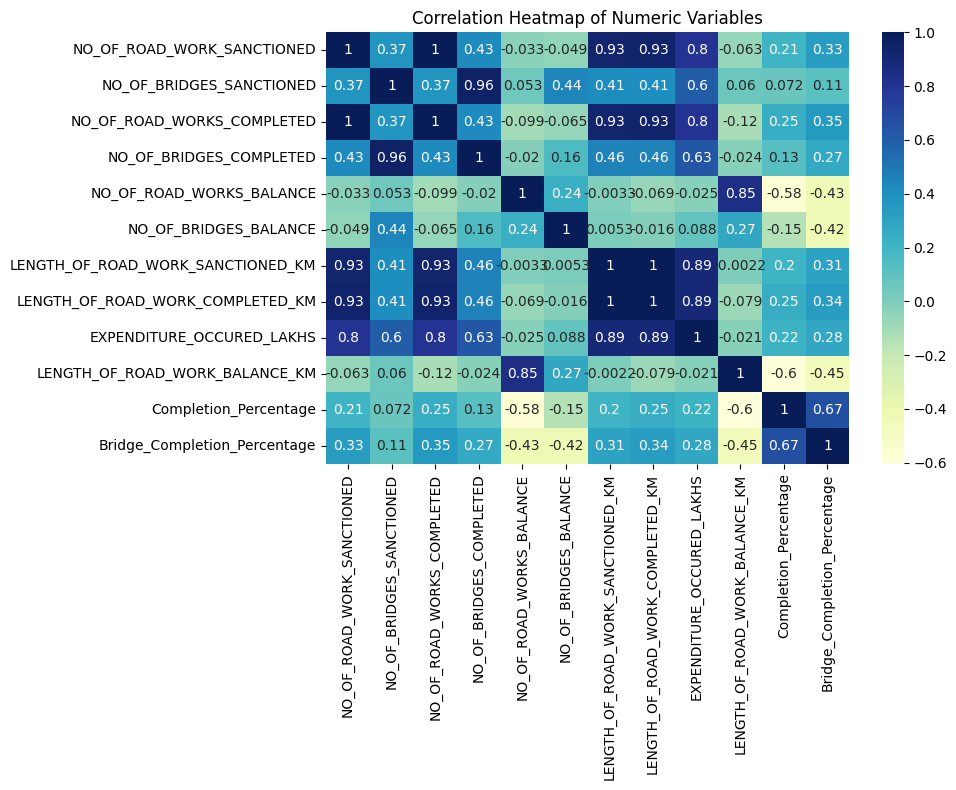

In [28]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(pdf.corr(numeric_only=True), annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()


* This shows consistency and logical coherence in the data: higher sanctioned projects correspond to higher completions and related costs.

* Variables measuring completion percentages may moderately correlate with their respective counts and lengths, indicating progress dependence on project size.

* The heatmap helps identify variables that move together, useful for feature selection and identifying key drivers in project performance.

* Low or weak correlations between certain variables suggest independent factors affecting distinct aspects of PMGSY implementation.

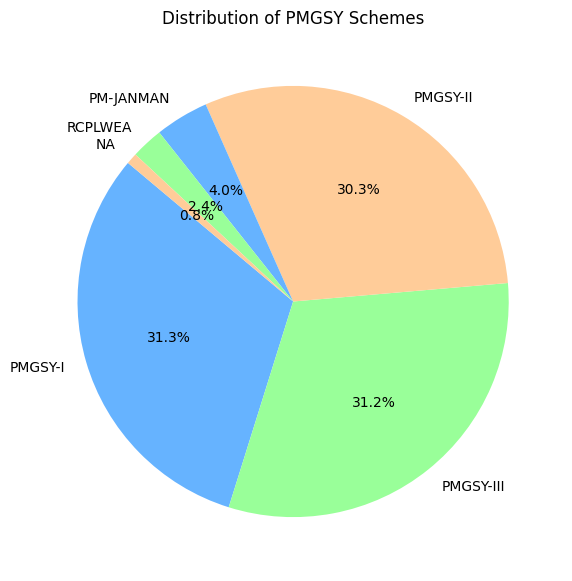

In [29]:
plt.figure(figsize=(7,7))
pdf["PMGSY_SCHEME"].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#99ff99','#ffcc99'])
plt.title("Distribution of PMGSY Schemes")
plt.ylabel("")
plt.show()


* The chart typically shows that PMGSY-I forms the largest portion, reflecting the extensive initial phase of the rural road connectivity program.

* PMGSY-II and PMGSY-III also represent significant but smaller parts, indicating continued phases with fewer but ongoing projects.

* The proportional representation suggests the dataset covers multiple scheme phases, illustrating the program's phased expansion over time.

* Color differentiation makes it easy to identify relative sizes, emphasizing the scheme with the most projects.

* This distribution helps understand the temporal and project volume landscape covered by PMGSY data.

* Aggregate key metrics for each PMGSY Scheme

In [31]:
scheme_summary = pdf.groupby("PMGSY_SCHEME").agg({
    "NO_OF_ROAD_WORK_SANCTIONED": "sum",
    "NO_OF_ROAD_WORKS_COMPLETED": "sum",
    "LENGTH_OF_ROAD_WORK_SANCTIONED_KM": "sum",
    "LENGTH_OF_ROAD_WORK_COMPLETED_KM": "sum",
    "COST_OF_WORKS_SANCTIONED_LAKHS": "sum",
    "EXPENDITURE_OCCURED_LAKHS": "sum"
}).reset_index()

* Calculate Completion Percentage

In [33]:
scheme_summary["Road_Completion_%"] = (
    scheme_summary["NO_OF_ROAD_WORKS_COMPLETED"] /
    scheme_summary["NO_OF_ROAD_WORK_SANCTIONED"]
) * 100

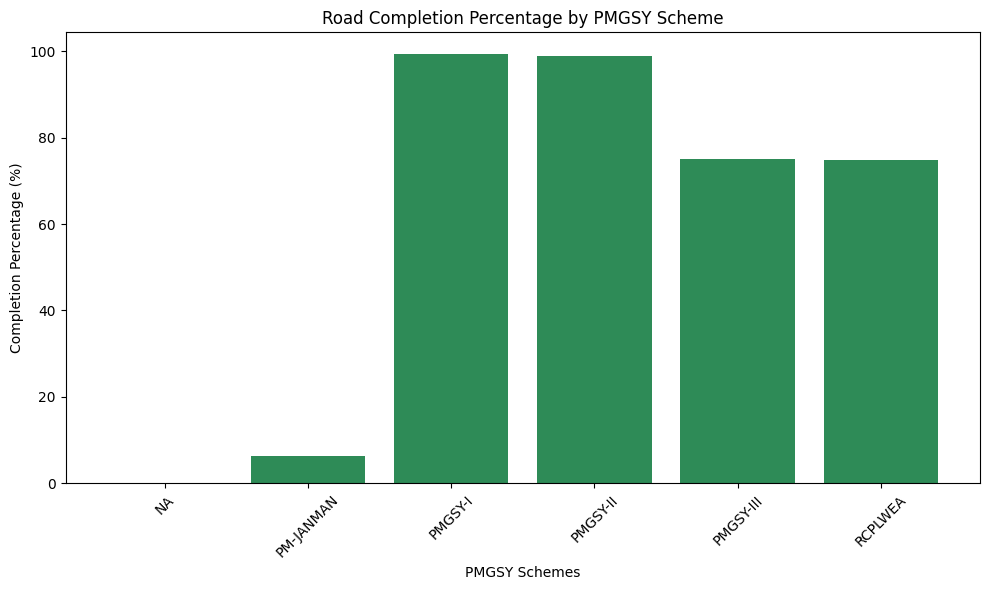

In [34]:
plt.figure(figsize=(10, 6))
plt.bar(scheme_summary["PMGSY_SCHEME"], scheme_summary["Road_Completion_%"], color="seagreen")
plt.title("Road Completion Percentage by PMGSY Scheme")
plt.xlabel("PMGSY Schemes")
plt.ylabel("Completion Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

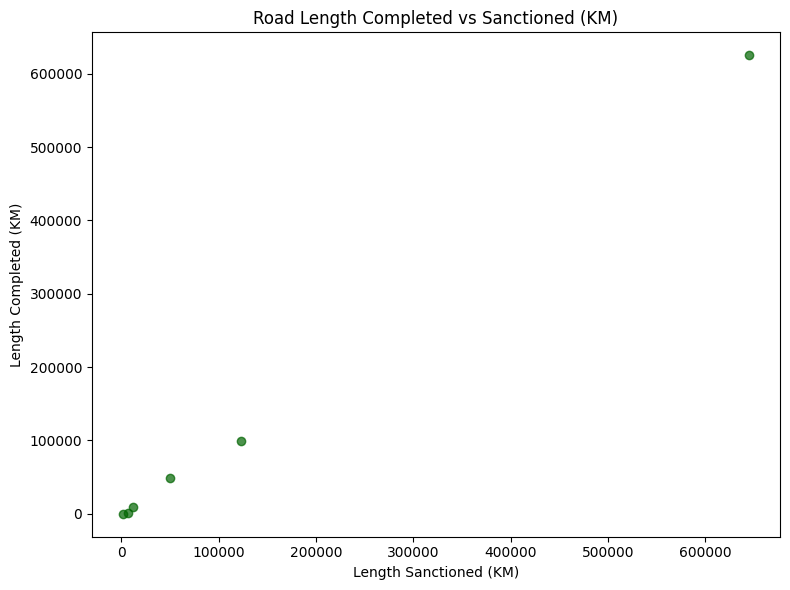

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(
    scheme_summary["LENGTH_OF_ROAD_WORK_SANCTIONED_KM"],
    scheme_summary["LENGTH_OF_ROAD_WORK_COMPLETED_KM"],
    color="darkgreen", alpha=0.7
)
plt.title("Road Length Completed vs Sanctioned (KM)")
plt.xlabel("Length Sanctioned (KM)")
plt.ylabel("Length Completed (KM)")
plt.tight_layout()
plt.show()

## Conclusion
The analysis effectively demonstrates how PySpark and Python analytics techniques can explore and visualize government infrastructure data at scale.
It sheds light on:

Infrastructure saturation in large states.

Resource utilization efficiency across phases.

Execution challenges in geographically constrained regions.

This dataset-driven approach provides valuable insights into the progress of India’s rural connectivity mission under PMGSY — highlighting both its successes and areas needing focused interventions.

In [66]:
spark.stop()